<a href="https://colab.research.google.com/github/Nawaf-Alorabi/EDA-Project/blob/main/EDA_Project_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Accidents Analysis in Saudi Arabia (1437–1439)

# Introduction

> #### This notebook analyzes traffic accident data in Saudi Arabiaacross three Hijri years (1437, 1438, 1439). The dataset contains monthly records for 16 cities, covering demographic details such as gender, age groups, and nationality of those involved in accidents. The goal is to explore patterns, identify high-risk cities, and build predictive models to support road safety decisions.



# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [2]:
df_1437 = pd.read_csv("Injured_and_Dead_in_Accidents_1437.csv", sep=";", encoding="utf-8-sig")
df_1438 = pd.read_csv("Injured_and_Dead_in_Accidents_1438.csv", sep=";", encoding="utf-8-sig")
df_1439 = pd.read_csv("Injured_and_Dead_in_Accidents_1439.csv", sep=";", encoding="utf-8-sig")

In [3]:
df = pd.concat([df_1437, df_1438, df_1439])

In [4]:
# save after make it in single file
# df.to_csv("accidents_1437_1439.csv", index=False, encoding="utf-8-sig")

# Data Overview

In [5]:
df.head()

,الشهر,سنة,المدينة,ذكور,أناث,داخل المدينه,خارج المدينه,أقل من 18,من18 إلى 30,من 30 على 40,من40إلى50,من50فأكثر,سعودى,غير سعودى,المصابين,المتوفين
0,1.0,1437.0,الرياض,91.0,6.0,49.0,48.0,15.0,31.0,40.0,5.0,6.0,56.0,41.0,0.0,1.0
1,2.0,1437.0,الرياض,93.0,9.0,52.0,50.0,14.0,33.0,34.0,9.0,12.0,66.0,36.0,0.0,1.0
2,3.0,1437.0,الرياض,101.0,2.0,61.0,42.0,15.0,35.0,29.0,13.0,11.0,52.0,51.0,0.0,1.0
3,4.0,1437.0,الرياض,116.0,10.0,53.0,73.0,21.0,42.0,35.0,15.0,13.0,62.0,64.0,0.0,1.0
4,5.0,1437.0,الرياض,81.0,12.0,51.0,42.0,16.0,28.0,26.0,14.0,9.0,43.0,50.0,0.0,1.0


In [6]:
df.shape

(1155, 16)

In [7]:
df.columns

Index(['الشهر', 'سنة', 'المدينة', 'ذكور', 'أناث', 'داخل المدينه',
       'خارج المدينه', 'أقل من 18', 'من18 إلى 30', 'من 30 على 40', 'من40إلى50',
       'من50فأكثر', 'سعودى', 'غير سعودى', 'المصابين', 'المتوفين'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 384
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   الشهر         1152 non-null   float64
 1   سنة           1152 non-null   float64
 2   المدينة       1152 non-null   object 
 3   ذكور          1152 non-null   float64
 4   أناث          1152 non-null   float64
 5   داخل المدينه  1152 non-null   float64
 6   خارج المدينه  1152 non-null   float64
 7   أقل من 18     1152 non-null   float64
 8   من18 إلى 30   1152 non-null   float64
 9   من 30 على 40  1152 non-null   float64
 10  من40إلى50     1152 non-null   float64
 11  من50فأكثر     1152 non-null   float64
 12  سعودى         1152 non-null   float64
 13  غير سعودى     1152 non-null   float64
 14  المصابين      1152 non-null   float64
 15  المتوفين      1152 non-null   float64
dtypes: float64(15), object(1)
memory usage: 153.4+ KB


# Data Cleaning

In [9]:
# show row that have null
print(df[df.isnull().any(axis=1)])

# Drop null
df.dropna(inplace=True)

     الشهر  سنة المدينة  ذكور  أناث  داخل المدينه  خارج المدينه  أقل من 18  \
384    NaN  NaN     NaN   NaN   NaN           NaN           NaN        NaN   
384    NaN  NaN     NaN   NaN   NaN           NaN           NaN        NaN   
384    NaN  NaN     NaN   NaN   NaN           NaN           NaN        NaN   

     من18 إلى 30  من 30 على 40  من40إلى50  من50فأكثر  سعودى  غير سعودى  \
384          NaN           NaN        NaN        NaN    NaN        NaN   
384          NaN           NaN        NaN        NaN    NaN        NaN   
384          NaN           NaN        NaN        NaN    NaN        NaN   

     المصابين  المتوفين  
384       NaN       NaN  
384       NaN       NaN  
384       NaN       NaN  


In [10]:
df.columns = [
    'month',         # الشهر
    'year',          # سنة
    'city',          # المدينة
    'males',         # ذكور
    'females',       # أناث
    'inside_city',   # داخل المدينه
    'outside_city',  # خارج المدينه
    'age_under18',   # أقل من 18
    'age_18_30',     # من18 إلى 30
    'age_30_40',     # من 30 على 40
    'age_40_50',     # من40إلى50
    'age_50plus',    # من50فأكثر
    'saudi',         # سعودى
    'non_saudi',     # غير سعودى
    'injuries',      # المصابين
    'deaths',        # المتوفين
]

print('Columns renamed')
df.columns.tolist()

Columns renamed


['month',
 'year',
 'city',
 'males',
 'females',
 'inside_city',
 'outside_city',
 'age_under18',
 'age_18_30',
 'age_30_40',
 'age_40_50',
 'age_50plus',
 'saudi',
 'non_saudi',
 'injuries',
 'deaths']

In [11]:
df['city'] = df['city'].replace({
    'الرياض'          : 'Riyadh',
    'جده'             : 'Jeddah',
    'المدينه المنوره': 'Madinah',
    'الشرقيه'         : 'Al-Sharqiyah',
    'الحدود الشماليه': 'Northern Borders',
    'تبوك'            : 'Tabuk',
    'الجوف'           : 'Al-Jouf',
    'حائل'            : 'Hail',
    'نجران'           : 'Najran',
    'القصيم'          : 'Al-Qassim',
    'الباحه'          : 'Al-Baha',
    'عسير'            : 'Asir',
    'جازان'           : 'Jazan',
    'الطائف'          : 'Taif',
    'العاصمه'         : 'Makkah',
    'القريات'         : 'Al-Qurayyat',
})

print(df['city'].value_counts())

city
Riyadh              72
Madinah             72
Al-Sharqiyah        72
Northern Borders    72
Tabuk               72
Al-Jouf             72
Hail                72
Najran              72
Al-Qassim           72
Al-Baha             72
Asir                72
Jazan               72
Jeddah              72
Taif                72
Makkah              72
Al-Qurayyat         72
Name: count, dtype: int64


In [12]:
df['total_accidents'] = df['males'] + df['females']

In [13]:
df['total_accidents'] = df['males'] + df['females']

# تحويل injuries و deaths إلى 0/1 فقط
df['injuries'] = (df['injuries'] > 0).astype(int)
df['deaths']  = (df['deaths']  > 0).astype(int)

print('has_injury:', df['injuries'].value_counts().to_dict())
print('has_death: ', df['deaths'].value_counts().to_dict())

has_injury: {0: 576, 1: 576}
has_death:  {1: 576, 0: 576}


In [14]:
df.head()

,month,year,city,males,females,inside_city,outside_city,age_under18,age_18_30,age_30_40,age_40_50,age_50plus,saudi,non_saudi,injuries,deaths,total_accidents
0,1.0,1437.0,Riyadh,91.0,6.0,49.0,48.0,15.0,31.0,40.0,5.0,6.0,56.0,41.0,0,1,97.0
1,2.0,1437.0,Riyadh,93.0,9.0,52.0,50.0,14.0,33.0,34.0,9.0,12.0,66.0,36.0,0,1,102.0
2,3.0,1437.0,Riyadh,101.0,2.0,61.0,42.0,15.0,35.0,29.0,13.0,11.0,52.0,51.0,0,1,103.0
3,4.0,1437.0,Riyadh,116.0,10.0,53.0,73.0,21.0,42.0,35.0,15.0,13.0,62.0,64.0,0,1,126.0
4,5.0,1437.0,Riyadh,81.0,12.0,51.0,42.0,16.0,28.0,26.0,14.0,9.0,43.0,50.0,0,1,93.0


In [15]:
df.groupby('year')['total_accidents'].sum()

,total_accidents
year,
1437.0,47151.0
1438.0,40688.0
1439.0,36242.0


# Key Visualizations

### 7.1 Total Accidents Over Time
A line chart showing the total number of accidents per year. Helps identify whether accidents are increasing or decreasing over the three-year period.

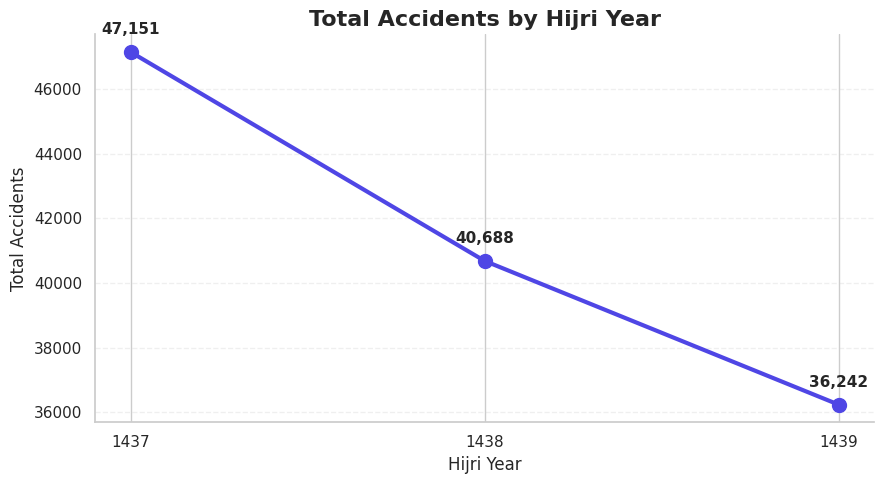

In [16]:
yearly = df.groupby('year', as_index=False)['total_accidents'].sum()

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9,5))

ax.plot(
    yearly['year'],
    yearly['total_accidents'],
    marker='o',
    markersize=10,
    linewidth=3,
    color='#4F46E5'
)

for x, y in zip(yearly['year'], yearly['total_accidents']):
    ax.text(
        x,
        y + 550,
        f'{int(y):,}',
        ha='center',
        fontsize=11,
        fontweight='bold',
    )

ax.set_title('Total Accidents by Hijri Year', fontsize=16, fontweight='bold')
ax.set_xlabel('Hijri Year')
ax.set_ylabel('Total Accidents')

ax.set_xticks([1437, 1438, 1439])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Monthly Accidents Heatmap
A heatmap showing total accidents per month for each year. Useful for spotting seasonal patterns and peak months.

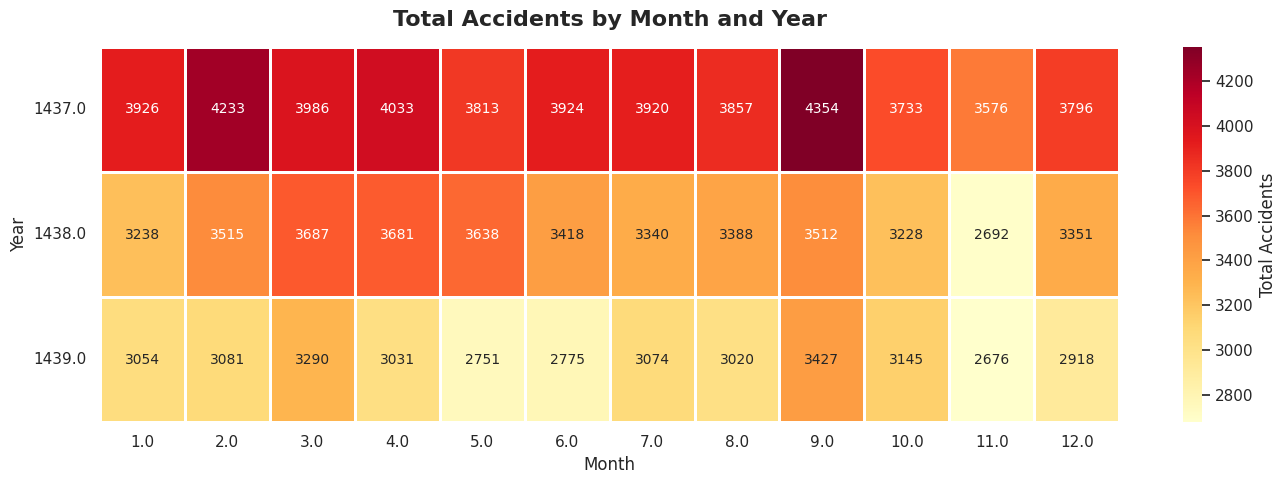

In [17]:
pivot = df.pivot_table(
    values='total_accidents',
    index='year',
    columns='month',
    aggfunc='sum'
)

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(14,5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=1,
    linecolor="white",
    annot_kws={"size":10},
    cbar_kws={"label":"Total Accidents"},
    ax=ax
)

ax.set_title(
    "Total Accidents by Month and Year",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month")
ax.set_ylabel("Year")

ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

### 7.3 Accidents by City
A horizontal bar chart ranking all 16 cities by total accidents. Identifies the most and least affected cities.

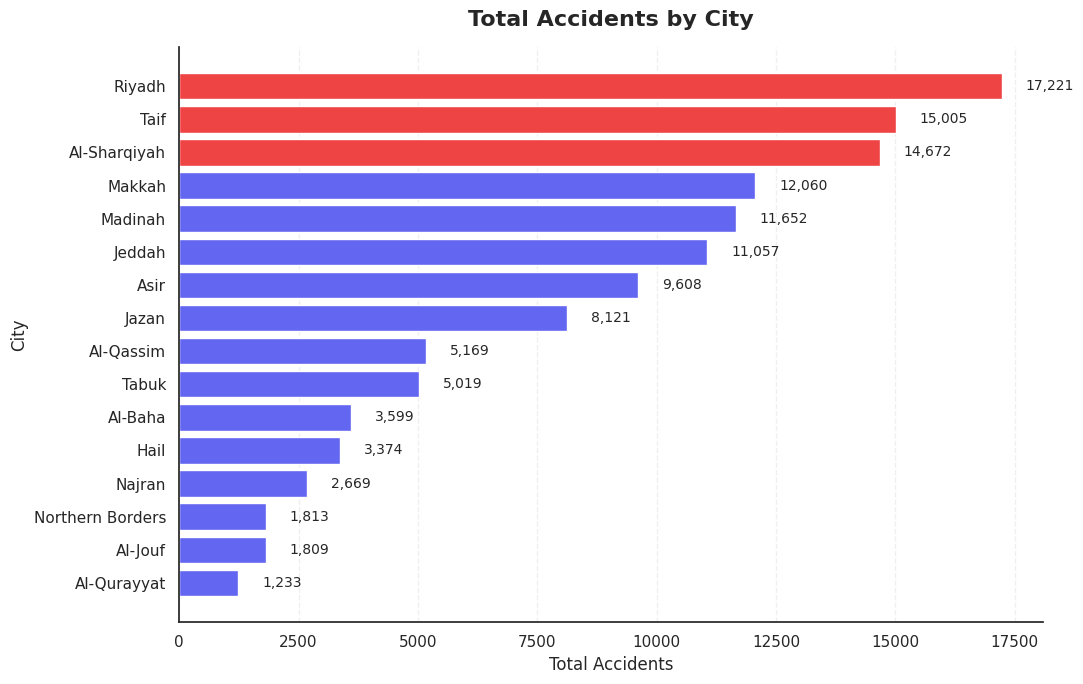

In [18]:
# ── VIZ: Accidents by City (Highlight Top 3) ─────────────────

city_totals = (
    df.groupby('city')['total_accidents']
    .sum()
    .sort_values()
)

# تحديد أخطر 3 مدن
top3 = city_totals.tail(3).index

# الألوان
colors = [
    '#EF4444' if city in top3 else '#6366F1'
    for city in city_totals.index
]

sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(11,7))

bars = ax.barh(
    city_totals.index,
    city_totals.values,
    color=colors
)

# كتابة القيم
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=10
    )

ax.set_title(
    'Total Accidents by City',
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('Total Accidents')
ax.set_ylabel('City')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.4 Age Group Distribution by City
A stacked bar chart showing the breakdown of age groups involved in accidents for the top 12 cities. Highlights which age groups are most at risk per city.

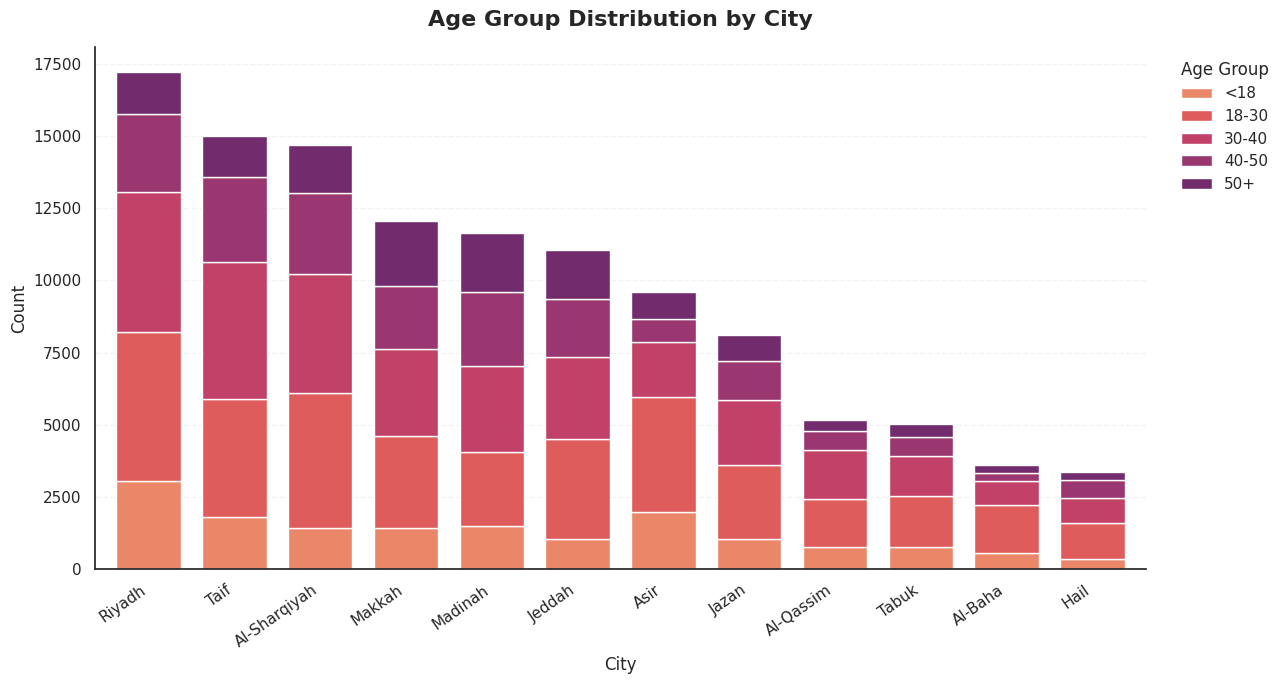

In [19]:
# ── Improved VIZ: Age Group Distribution by City ─────────────
age_cols = ['age_under18', 'age_18_30', 'age_30_40', 'age_40_50', 'age_50plus']

age_by_city = df.groupby('city')[age_cols].sum()
age_by_city.columns = ['<18', '18-30', '30-40', '40-50', '50+']

age_by_city = age_by_city.loc[age_by_city.sum(axis=1).nlargest(12).index]
age_by_city = age_by_city.loc[age_by_city.sum(axis=1).sort_values(ascending=False).index]

sns.set_theme(style="white")

colors = sns.color_palette("flare", 5)

fig, ax = plt.subplots(figsize=(13,7))

age_by_city.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=colors,
    width=0.75,
    edgecolor='white'
)

ax.set_title('Age Group Distribution by City', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('City')
ax.set_ylabel('Count')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.25)

plt.xticks(rotation=35, ha='right')
ax.legend(title='Age Group', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)

plt.tight_layout()
plt.show()

### 7.5 Gender Distribution
A pie chart showing the male vs female ratio among those involved in accidents across all records.

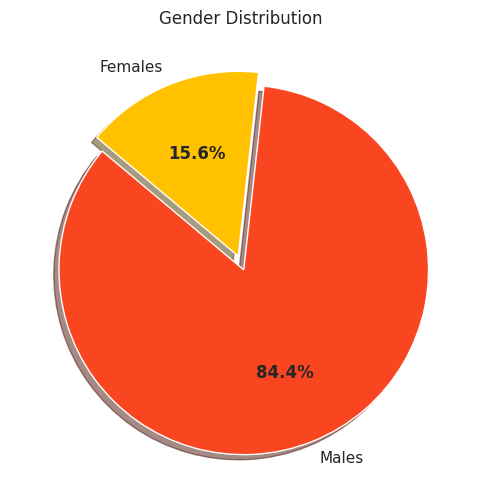

In [40]:
gender_totals = df[['males', 'females']].sum()

fig, ax = plt.subplots(figsize=(8,6))

colors = ['#FA4620', '#FFC100']   # أحمر + أحمر فاتح

wedges, texts, autotexts = ax.pie(
    gender_totals,
    labels=['Males', 'Females'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.04, 0.04),
    shadow=True
)

# جعل الأرقام Bold
for t in autotexts:
    t.set_fontweight('bold')
    t.set_fontsize(12)

ax.set_title('Gender Distribution')

plt.show()

### 7.6 Saudi vs Non-Saudi by City
A grouped bar chart comparing Saudi and non-Saudi involvement in accidents for the top 12 cities.

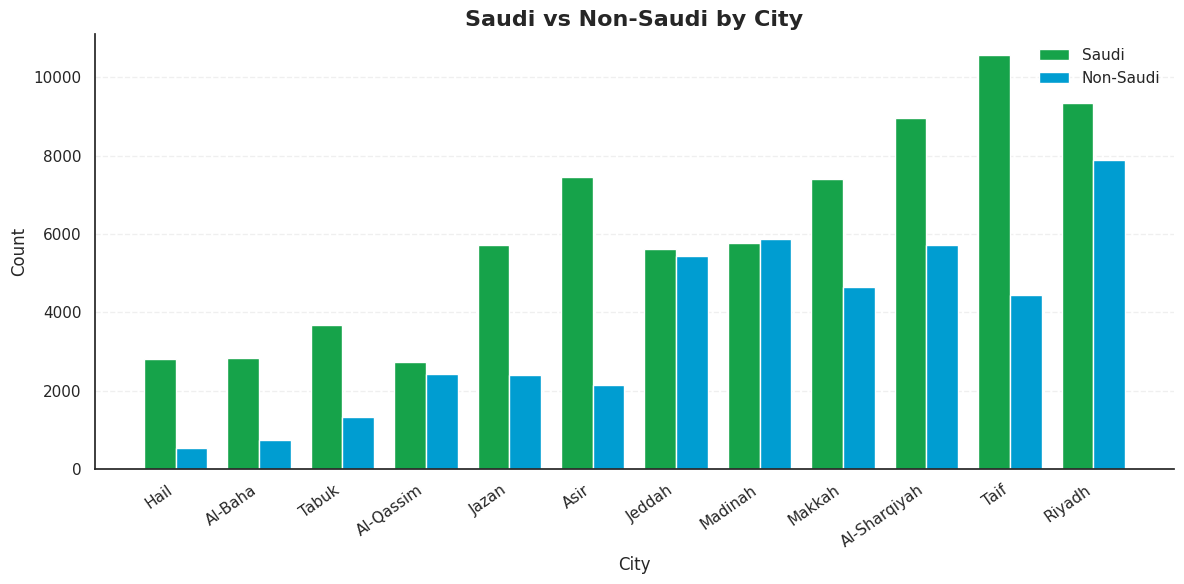

In [41]:
# ── VIZ 6: Saudi vs Non-Saudi by City ────────────────────────
nat = df.groupby('city')[['saudi', 'non_saudi']].sum()

# أعلى 12 مدينة
nat = nat.loc[nat.sum(axis=1).nlargest(12).index]

# ترتيب المدن
nat = nat.loc[nat.sum(axis=1).sort_values().index]

x = np.arange(len(nat))
w = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - w/2, nat['saudi'], width=w, label='Saudi', color='#16A34A')
ax.bar(x + w/2, nat['non_saudi'], width=w, label='Non-Saudi', color='#009DD1')

ax.set_xticks(x)
ax.set_xticklabels(nat.index, rotation=35, ha='right')

ax.set_title('Saudi vs Non-Saudi by City', fontsize=16, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('City')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

### 7.7 Inside vs Outside City
A box plot comparing the distribution of accidents that occurred inside vs outside city boundaries. Reveals differences in volume and spread.

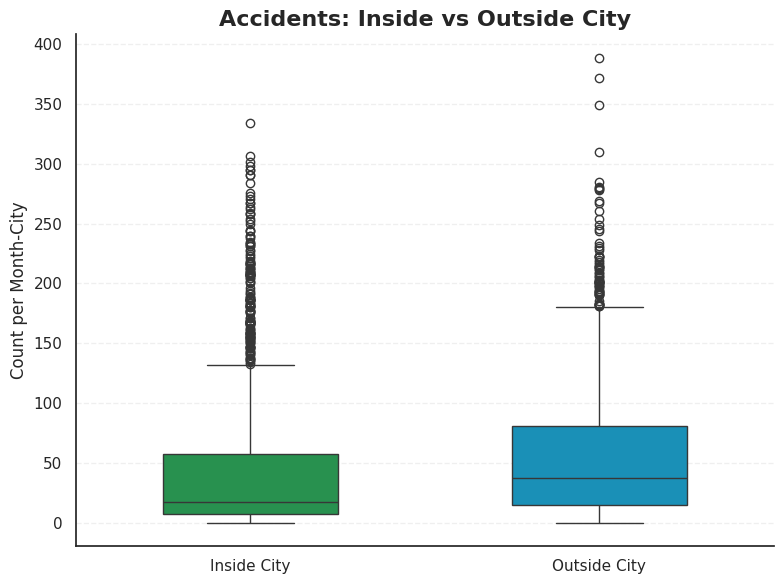

In [42]:
# ── Improved VIZ 7: Inside vs Outside City ──────────────────
melted = df[['inside_city', 'outside_city']].melt(
    var_name='Location',
    value_name='Accidents'
)

melted['Location'] = melted['Location'].map({
    'inside_city': 'Inside City',
    'outside_city': 'Outside City'
})

fig, ax = plt.subplots(figsize=(8,6))

sns.boxplot(
    data=melted,
    x='Location',
    y='Accidents',
    hue='Location',
    palette=['#16A34A', '#009DD1'],
    legend=False,
    width=0.5,
    ax=ax
)
ax.set_title('Accidents: Inside vs Outside City', fontsize=16, fontweight='bold')
ax.set_ylabel('Count per Month-City')
ax.set_xlabel('')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 7.8 Correlation Heatmap
A heatmap showing the correlation between all numeric features. Helps identify which variables are strongly related to each other.

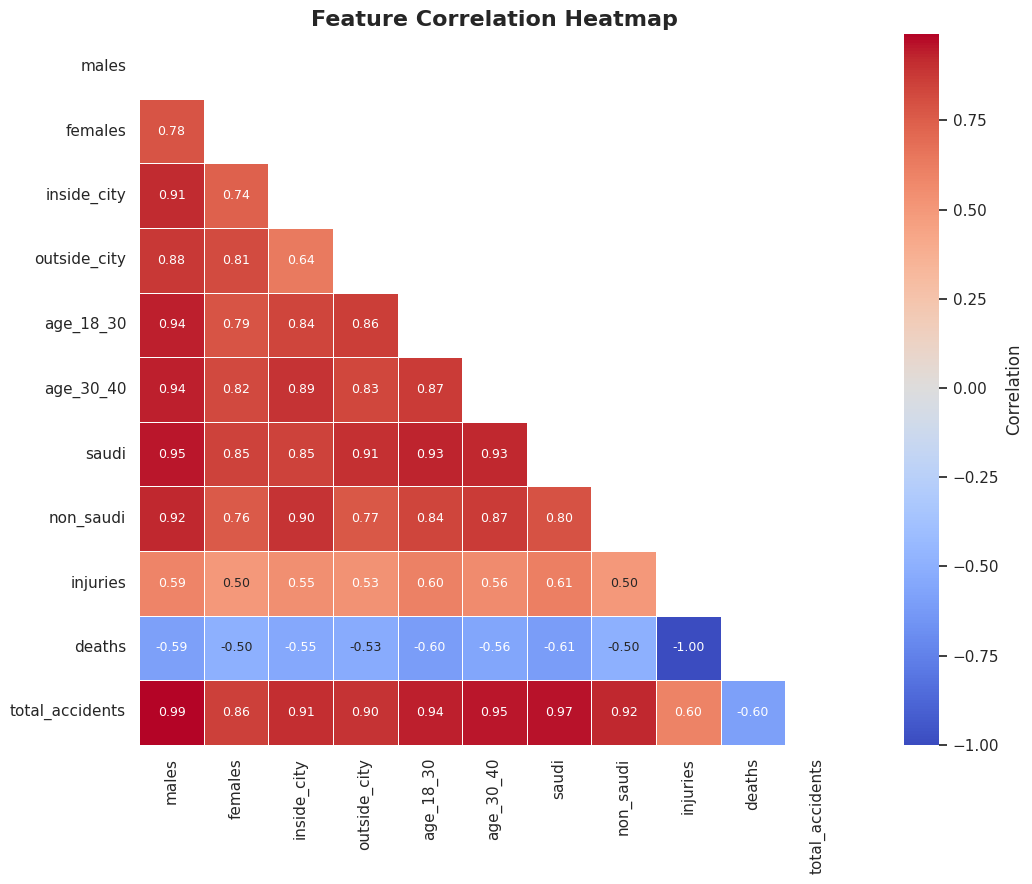

In [23]:
# ── 7.8 Correlation Heatmap ─────────────────────────────────
num_cols = [
    'males', 'females', 'inside_city', 'outside_city',
    'age_18_30', 'age_30_40',
    'saudi', 'non_saudi',
    'injuries', 'deaths',
    'total_accidents'
]

corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12,9))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.6,
    square=True,
    annot_kws={'size':9},
    cbar_kws={'label': 'Correlation'},
    ax=ax
)

ax.set_title(
    'Feature Correlation Heatmap',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Insights
Key findings extracted from the visualizations:
- Total accidents show a **consistent decline** from 1437 to 1439
- **Males** represent the overwhelming majority of those involved
- The **18–30 age group** is the most frequently involved across all cities
- **Riyadh** records the highest number of accidents by a significant margin
- Accidents **outside the city** show higher spread and more extreme values
- **Month 9** consistently shows a spike across all three years

# ML Model 1

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [25]:
# ── Step 1: Prepare Monthly Data ─────────────────────────────
monthly = (
    df.groupby(['year', 'month'])['total_accidents']
    .sum()
    .reset_index()
    .sort_values(['year', 'month'])
    .reset_index(drop=True)
)

# إنشاء مؤشر زمني
monthly['time_index'] = range(1, len(monthly) + 1)

In [26]:
# ── Step 2: Train Linear Regression Model ────────────────────
X = monthly[['time_index', 'month']]
y = monthly['total_accidents']

model = LinearRegression()
model.fit(X, y)

# التنبؤ على البيانات الحالية
monthly['predicted'] = model.predict(X)

In [27]:
# ── Step 3: Evaluate Model ───────────────────────────────────
r2 = r2_score(y, monthly['predicted'])
mae = mean_absolute_error(y, monthly['predicted'])

print("Model Performance")
print(f"R²  = {r2:.2f}")
print(f"MAE = {mae:.0f}")

Model Performance
R²  = 0.77
MAE = 150


In [28]:
# ── Step 4: Create Future Data ───────────────────────────────
last_time = monthly['time_index'].max()
last_year = monthly['year'].iloc[-1]
last_month = monthly['month'].iloc[-1]

future_rows = []
year = last_year
month = last_month

for i in range(1, 7):
    month += 1
    if month > 12:
        month = 1
        year += 1

    future_rows.append({
        'year': year,
        'month': month,
        'time_index': last_time + i
    })

future_df = pd.DataFrame(future_rows)

In [29]:
# ── Step 5: Predict Future Accidents ─────────────────────────
future_df['predicted'] = model.predict(
    future_df[['time_index', 'month']]
)

print("Future Forecast")
future_df[['year', 'month', 'predicted']]

Future Forecast


,year,month,predicted
0,1440.0,1,2675.438034
1,1440.0,2,2650.378594
2,1440.0,3,2625.319153
3,1440.0,4,2600.259713
4,1440.0,5,2575.200272
5,1440.0,6,2550.140831


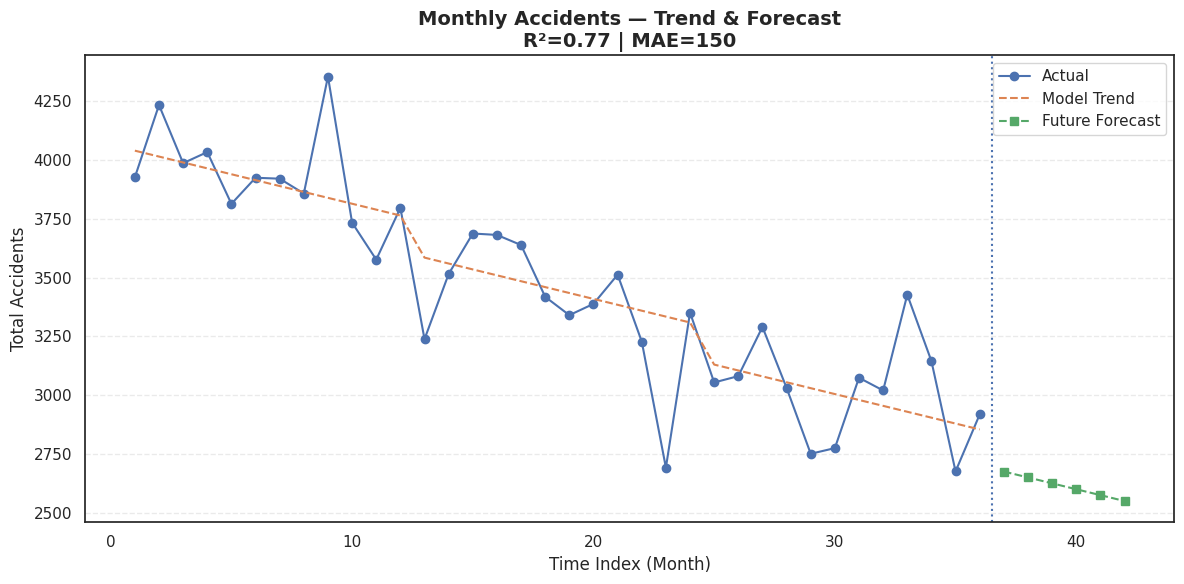

In [30]:
# ── Step 6: Plot Results ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(12,6))

# البيانات الحقيقية
ax.plot(
    monthly['time_index'],
    monthly['total_accidents'],
    marker='o',
    label='Actual'
)

# التوقعات داخل البيانات
ax.plot(
    monthly['time_index'],
    monthly['predicted'],
    linestyle='--',
    label='Model Trend'
)

# التنبؤ المستقبلي
ax.plot(
    future_df['time_index'],
    future_df['predicted'],
    marker='s',
    linestyle='--',
    label='Future Forecast'
)

ax.axvline(x=monthly['time_index'].max()+0.5, linestyle=':')

ax.set_title(
    f'Monthly Accidents — Trend & Forecast\nR²={r2:.2f} | MAE={mae:.0f}',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('Time Index (Month)')
ax.set_ylabel('Total Accidents')

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

 ## ML Model 2 - Clustering Model  K-Means

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── Step 1: تجميع البيانات على مستوى المدينة ─────────────────
city_df = df.groupby('city')[['deaths', 'injuries', 'outside_city', 'age_18_30']].mean().reset_index()

print('City-level averages:')
city_df

City-level averages:


,city,deaths,injuries,outside_city,age_18_30
0,Al-Baha,0.5,0.5,25.208333,22.750000
1,Al-Jouf,0.5,0.5,16.097222,8.750000
2,Al-Qassim,0.5,0.5,25.041667,23.138889
3,Al-Qurayyat,0.5,0.5,9.972222,7.027778
4,Al-Sharqiyah,0.5,0.5,95.125000,64.916667
5,Asir,0.5,0.5,123.111111,55.305556
6,Hail,0.5,0.5,21.680556,17.236111
7,Jazan,0.5,0.5,78.625000,35.500000
8,Jeddah,0.5,0.5,59.083333,47.888889
9,Madinah,0.5,0.5,94.097222,35.597222


In [32]:
# K-Means حساس للمقاييس — لازم نوحّد الأعمدة قبل التدريب
features = ['deaths', 'injuries', 'outside_city', 'age_18_30']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(city_df[features])

print('Data scaled')

Data scaled


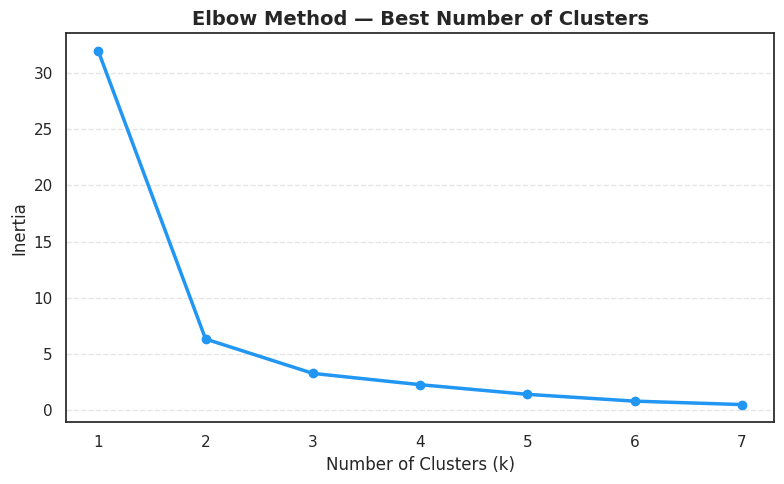

In [33]:
# ── Step 3: Elbow Method — إيجاد أفضل عدد clusters ──────────
inertias = []
k_range  = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(k_range, inertias, marker='o', linewidth=2.5, color='#2196F3')
ax.set_title('Elbow Method — Best Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [34]:
# ── Step 4: تدريب النموذج بـ k=3 ────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=10)
city_df['cluster'] = km.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, city_df['cluster'])

print(f'Model trained  |  Silhouette Score: {sil:.4f}')
print()
print(city_df[['city', 'cluster', 'outside_city', 'age_18_30']].sort_values('cluster').to_string(index=False))

Model trained  |  Silhouette Score: 0.5896

            city  cluster  outside_city  age_18_30
            Asir        0    123.111111  55.305556
    Al-Sharqiyah        0     95.125000  64.916667
          Riyadh        0     93.777778  71.194444
            Taif        0    122.263889  56.777778
     Al-Qurayyat        1      9.972222   7.027778
       Al-Qassim        1     25.041667  23.138889
         Al-Baha        1     25.208333  22.750000
         Al-Jouf        1     16.097222   8.750000
           Tabuk        1     48.236111  24.444444
            Hail        1     21.680556  17.236111
          Najran        1     24.875000  11.902778
Northern Borders        1     15.500000   8.861111
           Jazan        2     78.625000  35.500000
          Makkah        2     95.708333  44.333333
          Jeddah        2     59.083333  47.888889
         Madinah        2     94.097222  35.597222


In [35]:
# ── Step 5: تسمية المجموعات ──────────────────────────────────
cluster_names = {
    0 : 'Low Risk',     # حوادث قليلة — مدن صغيرة
    1 : 'High Risk',    # حوادث كثيرة — مدن كبيرة
    2 : 'Medium Risk',  # حوادث متوسطة
}

city_df['cluster_label'] = city_df['cluster'].replace(cluster_names)

print(city_df[['city', 'cluster_label']].sort_values('cluster_label').to_string(index=False))

            city cluster_label
         Al-Baha     High Risk
         Al-Jouf     High Risk
       Al-Qassim     High Risk
     Al-Qurayyat     High Risk
            Hail     High Risk
          Najran     High Risk
Northern Borders     High Risk
           Tabuk     High Risk
    Al-Sharqiyah      Low Risk
            Asir      Low Risk
          Riyadh      Low Risk
            Taif      Low Risk
           Jazan   Medium Risk
          Jeddah   Medium Risk
         Madinah   Medium Risk
          Makkah   Medium Risk


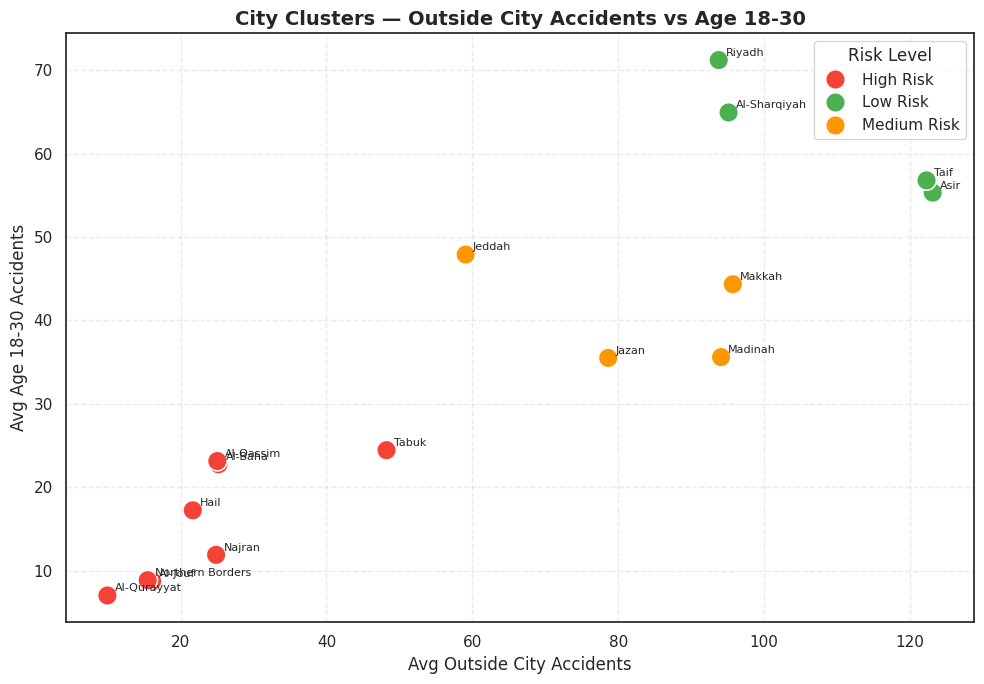

In [36]:
# ── Step 6: رسم المجموعات ────────────────────────────────────
palette = {'Low Risk': '#4CAF50', 'Medium Risk': '#FF9800', 'High Risk': '#F44336'}

fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(
    data=city_df,
    x='outside_city',
    y='age_18_30',
    hue='cluster_label',
    palette=palette,
    s=200,
    ax=ax
)

for _, row in city_df.iterrows():
    ax.text(row['outside_city'] + 1, row['age_18_30'] + 0.5, row['city'], fontsize=8)

ax.set_title('City Clusters — Outside City Accidents vs Age 18-30', fontsize=14, fontweight='bold')
ax.set_xlabel('Avg Outside City Accidents')
ax.set_ylabel('Avg Age 18-30 Accidents')
ax.legend(title='Risk Level')
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [37]:
# ── Step 7: مقارنة المجموعات ─────────────────────────────────
summary = city_df.groupby('cluster_label')[features].mean().round(2)

print('===== Cluster Summary =====')
print(summary.to_string())

===== Cluster Summary =====
               deaths  injuries  outside_city  age_18_30
cluster_label                                           
High Risk         0.5       0.5         23.33      15.51
Low Risk          0.5       0.5        108.57      62.05
Medium Risk       0.5       0.5         81.88      40.83


# Conclusion



> This analysis reveals a positive trend of declining traffic accidents in Saudi Arabia between 1437 and 1439. Young males aged 18–30 remain the highest-risk demographic. Major cities — particularly Riyadh — require continued attention due to their consistently high accident volumes. The predictive model suggests this decline will continue into 1440 if current conditions hold. City clustering provides a practical tool for prioritizing safety interventions based on risk level.

